# **CIFAR-10 Image Classification — ANN vs CNN**

### CEI Week-4 Assignment

**Objective:** Build and compare ANN and CNN models on CIFAR-10 dataset

**Dataset:** CIFAR-10 — 60,000 color images (32x32) across 10 classes

**Models:**
- Baseline ANN (flattened input)
- CNN with Conv2D + BatchNorm + Pooling
- Advanced CNN with data augmentation

**Tasks:** Compare accuracy, train for 10/20 epochs, use EarlyStopping, analyze results

## Step 1: Load CIFAR-10

Load 50,000 training images + 10,000 test images (32x32 RGB)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten,
    Conv2D, MaxPooling2D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_tr, y_tr), (x_te, y_te) = cifar10.load_data()

print("Training images:", x_tr.shape)
print("Training labels:", y_tr.shape)
print("Test images    :", x_te.shape)
print("Test labels    :", y_te.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3237s 19us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images    : (10000, 32, 32, 3)
Test labels    : (10000, 1)


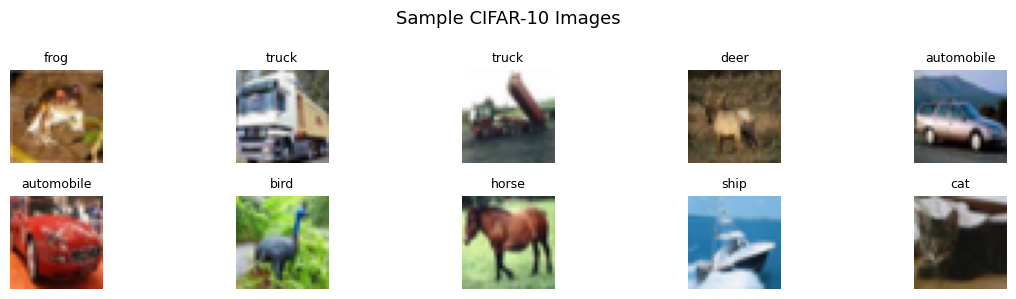

In [3]:
# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Show sample images
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_tr[i])
    plt.title(class_names[y_tr[i][0]], fontsize=9)
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontsize=13)
plt.tight_layout()
plt.show()

## Step 2: Normalize Images

Convert pixel values from [0, 255] → [0.0, 1.0] to stabilize gradients

In [4]:
x_tr = x_tr.astype('float32') / 255.0
x_te = x_te.astype('float32') / 255.0

print("Normalized")
print("  Min:", x_tr.min())
print("  Max:", x_tr.max())
print("  Mean:", x_tr.mean().round(3))

Normalized
  Min: 0.0
  Max: 1.0
  Mean: 0.473


## Step 3: Build ANN

Flatten 32x32x3 → 3072 vector, use Dense + Dropout layers

In [5]:
ann = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
], name='ANN')

ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Build CNN

Use Conv2D → BatchNorm → MaxPooling → Dense layers

In [6]:
cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='CNN')

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

## Step 5: Compile Models

Both use Adam optimizer + sparse categorical cross-entropy

In [7]:
ann.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Models compiled")

Models compiled


## Step 6: Train ANN (10 epochs)

In [8]:
h_ann = ann.fit(
    x_tr, y_tr,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.1978 - loss: 2.1332 - val_accuracy: 0.2691 - val_loss: 1.9814
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2474 - loss: 2.0108 - val_accuracy: 0.3035 - val_loss: 1.8918
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2559 - loss: 1.9777 - val_accuracy: 0.2838 - val_loss: 1.9135
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2670 - loss: 1.9502 - val_accuracy: 0.3246 - val_loss: 1.8589
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2821 - loss: 1.9258 - val_accuracy: 0.3319 - val_loss: 1.8420
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2864 - loss: 1.9104 - val_accuracy: 0.3332 - val_loss: 1.8560
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2885 - loss: 1.9033 - val_accuracy: 0.3236 - val_loss: 1.8639
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2940 - loss: 1.8946 - val_accuracy: 0

## Step 7: Train CNN (10 epochs)

In [9]:
h_cnn = cnn.fit(
    x_tr, y_tr,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.3586 - loss: 1.7900 - val_accuracy: 0.2441 - val_loss: 3.6217
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4915 - loss: 1.4213 - val_accuracy: 0.5791 - val_loss: 1.1855
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5531 - loss: 1.2532 - val_accuracy: 0.5612 - val_loss: 1.2985
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5938 - loss: 1.1468 - val_accuracy: 0.5948 - val_loss: 1.1576
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6271 - loss: 1.0570 - val_accuracy: 0.6282 - val_loss: 1.0421
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6565 - loss: 0.9765 - val_accuracy: 0.6799 - val_loss: 0.9386
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6765 - loss: 0.9054 - val_accuracy: 0.6324 - val_loss: 1.0936
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7002 - loss: 0.8451 - val_accuracy: 

## Step 8: Validation Accuracy Comparison Plot

Plot ANN vs CNN validation accuracy side-by-side

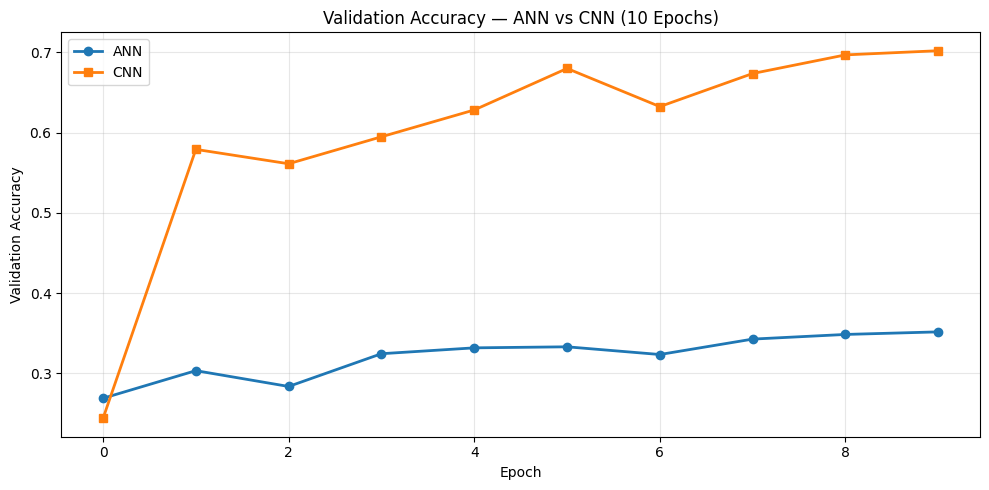

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(h_ann.history['val_accuracy'], marker='o', label='ANN', linewidth=2)
plt.plot(h_cnn.history['val_accuracy'], marker='s', label='CNN', linewidth=2)
plt.title("Validation Accuracy — ANN vs CNN (10 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: Test Evaluation

Evaluate both models on test set

In [18]:
ann_loss, ann_acc = ann.evaluate(x_te, y_te, verbose=0)
cnn_loss, cnn_acc = cnn.evaluate(x_te, y_te, verbose=0)

print("=" * 45)
print("TEST SET EVALUATION")
print("=" * 45)
print(f"  ANN — Accuracy: {ann_acc:.4f}  |  Loss: {ann_loss:.4f}")
print(f"  CNN — Accuracy: {cnn_acc:.4f}  |  Loss: {cnn_loss:.4f}")

TEST SET EVALUATION
  ANN — Accuracy: 0.3556  |  Loss: 1.8205
  CNN — Accuracy: 0.6961  |  Loss: 0.8928


## Step 10: Improved ANN Architecture



In [33]:
ann2 = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
], name='ANN_v2')

ann2.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h_ann2 = ann2.fit(
    x_tr, y_tr,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

ann2_loss, ann2_acc = ann2.evaluate(x_te, y_te, verbose=0)
print(f"\nANN v2 Test Accuracy: {ann2_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.1815 - loss: 2.1570 - val_accuracy: 0.2151 - val_loss: 2.0415
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2184 - loss: 2.0501 - val_accuracy: 0.2823 - val_loss: 1.9386
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2409 - loss: 2.0043 - val_accuracy: 0.2915 - val_loss: 1.9128
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2513 - loss: 1.9885 - val_accuracy: 0.2633 - val_loss: 1.9329
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2639 - loss: 1.9640 - val_accuracy: 0.2815 - val_loss: 1.9199
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2660 - loss: 1.9543 - val_accuracy: 0.3087 - val_loss: 1.9070
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2772 - loss: 1.9423 - val_accuracy: 0.2969 - val_loss: 1.9099
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2785 - loss: 1.9359 - val_accuracy: 0

## Step 11: Enhanced CNN (32→64→128 Filters)


In [34]:
cnn2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='CNN_v2')

cnn2.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h_cnn2 = cnn2.fit(
    x_tr, y_tr,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

cnn2_loss, cnn2_acc = cnn2.evaluate(x_te, y_te, verbose=0)
print(f"\nCNN v2 (32→64→128) Test Accuracy: {cnn2_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.4072 - loss: 1.6804 - val_accuracy: 0.2399 - val_loss: 3.9160
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5529 - loss: 1.2640 - val_accuracy: 0.5854 - val_loss: 1.1610
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6318 - loss: 1.0387 - val_accuracy: 0.5571 - val_loss: 1.3115
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6881 - loss: 0.8881 - val_accuracy: 0.6590 - val_loss: 1.0137
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7281 - loss: 0.7744 - val_accuracy: 0.6349 - val_loss: 1.1365
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7596 - loss: 0.6744 - val_accuracy: 0.6435 - val_loss: 1.0902
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7911 - loss: 0.5820 - val_accuracy: 0.7001 - val_loss: 0.9870
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8128 - loss: 0.5218 - val_accuracy:

## Step 12: CNN Training for 20 Epochs


In [35]:
cnn3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='CNN_20ep')

cnn3.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h_cnn3 = cnn3.fit(
    x_tr, y_tr,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

cnn3_loss, cnn3_acc = cnn3.evaluate(x_te, y_te, verbose=0)
print(f"\nCNN (20 epochs) Test Accuracy: {cnn3_acc:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3511 - loss: 1.7877 - val_accuracy: 0.2788 - val_loss: 3.1166
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4801 - loss: 1.4360 - val_accuracy: 0.5665 - val_loss: 1.2197
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5449 - loss: 1.2650 - val_accuracy: 0.5482 - val_loss: 1.2673
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5933 - loss: 1.1504 - val_accuracy: 0.6150 - val_loss: 1.1040
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6282 - loss: 1.0518 - val_accuracy: 0.6678 - val_loss: 0.9451
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6517 - loss: 0.9814 - val_accuracy: 0.6590 - val_loss: 0.9641
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6734 - loss: 0.9204 - val_accuracy: 0.6411 - val_loss: 1.0512
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6970 - loss: 0.8574 - val_accuracy: 

## Step 13: CNN with EarlyStopping



In [36]:
cnn4 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='CNN_EarlyStop')

cnn4.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

h_cnn4 = cnn4.fit(
    x_tr, y_tr,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

cnn4_loss, cnn4_acc = cnn4.evaluate(x_te, y_te, verbose=0)
print(f"\nCNN + EarlyStopping Test Accuracy: {cnn4_acc:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.3595 - loss: 1.8060 - val_accuracy: 0.2769 - val_loss: 2.9132
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4945 - loss: 1.4103 - val_accuracy: 0.5169 - val_loss: 1.4540
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5624 - loss: 1.2299 - val_accuracy: 0.6002 - val_loss: 1.1238
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6008 - loss: 1.1296 - val_accuracy: 0.6569 - val_loss: 0.9910
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6302 - loss: 1.0489 - val_accuracy: 0.6321 - val_loss: 1.0788
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6603 - loss: 0.9683 - val_accuracy: 0.6385 - val_loss: 1.0577
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6806 - loss: 0.9087 - val_accuracy: 0.6605 - val_loss: 0.9755
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7031 - loss: 0.8437 - val_accuracy: 

## Step 14: Data Augmentation (Flip, Rotation, Zoom)



In [37]:
aug = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='augment')

cnn5 = Sequential([
    aug,
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='CNN_Aug')

cnn5.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h_cnn5 = cnn5.fit(
    x_tr, y_tr,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    # Removed callbacks=[es] to allow full 20 epochs of training for augmented data
    verbose=1
)

cnn5_loss, cnn5_acc = cnn5.evaluate(x_te, y_te, verbose=0)
print(f"\nCNN + Augmentation Test Accuracy: {cnn5_acc:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.3158 - loss: 1.8880 - val_accuracy: 0.2320 - val_loss: 3.4345
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4200 - loss: 1.5975 - val_accuracy: 0.5474 - val_loss: 1.2795
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4852 - loss: 1.4410 - val_accuracy: 0.5439 - val_loss: 1.3331
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5212 - loss: 1.3408 - val_accuracy: 0.4390 - val_loss: 2.0633
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5519 - loss: 1.2674 - val_accuracy: 0.6137 - val_loss: 1.1293
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5746 - loss: 1.2084 - val_accuracy: 0.6295 - val_loss: 1.0747
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5968 - loss: 1.1502 - val_accuracy: 0.5955 - val_loss: 1.1681
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6174 - loss: 1.1066 - val_acc

---

# **Final Results**

Compare all models and visualize performance

## Step 15: Final Comparison DataFrame

Summary of all model test accuracies

In [38]:
results = pd.DataFrame({
    'Model': [
        'ANN',
        'CNN',
        'ANN v2 (more layers)',
        'CNN v2 (32→64→128)',
        'CNN (20 epochs)',
        'CNN + EarlyStopping',
        'CNN + Augmentation'
    ],
    'Test Accuracy': [
        ann_acc,
        cnn_acc,
        ann2_acc,
        cnn2_acc,
        cnn3_acc,
        cnn4_acc,
        cnn5_acc
    ]
})

results['Test Accuracy'] = results['Test Accuracy'].round(4)
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print("=" * 60)
print("FINAL RESULTS — ALL MODELS")
print("=" * 60)
print(results.to_string(index=False))

FINAL RESULTS — ALL MODELS
               Model  Test Accuracy
  CNN + Augmentation         0.7267
  CNN v2 (32→64→128)         0.7165
 CNN + EarlyStopping         0.7105
     CNN (20 epochs)         0.7054
                 CNN         0.6961
                 ANN         0.3556
ANN v2 (more layers)         0.3119


## Step 16: Accuracy Comparison Chart

Visualize model performance with bar chart

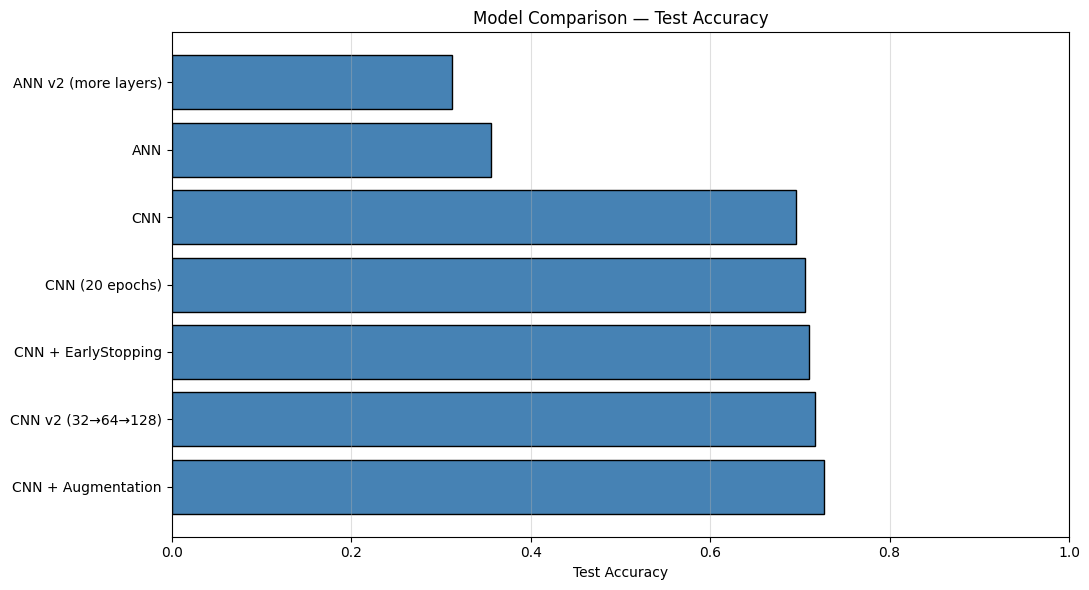

In [39]:
plt.figure(figsize=(11, 6))
plt.barh(results['Model'], results['Test Accuracy'], color='steelblue', edgecolor='black')
plt.xlabel("Test Accuracy")
plt.title("Model Comparison — Test Accuracy")
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## Step 17: Predictions on Test Images

Predict on 15 random test images using best model (CNN with Augmentation)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


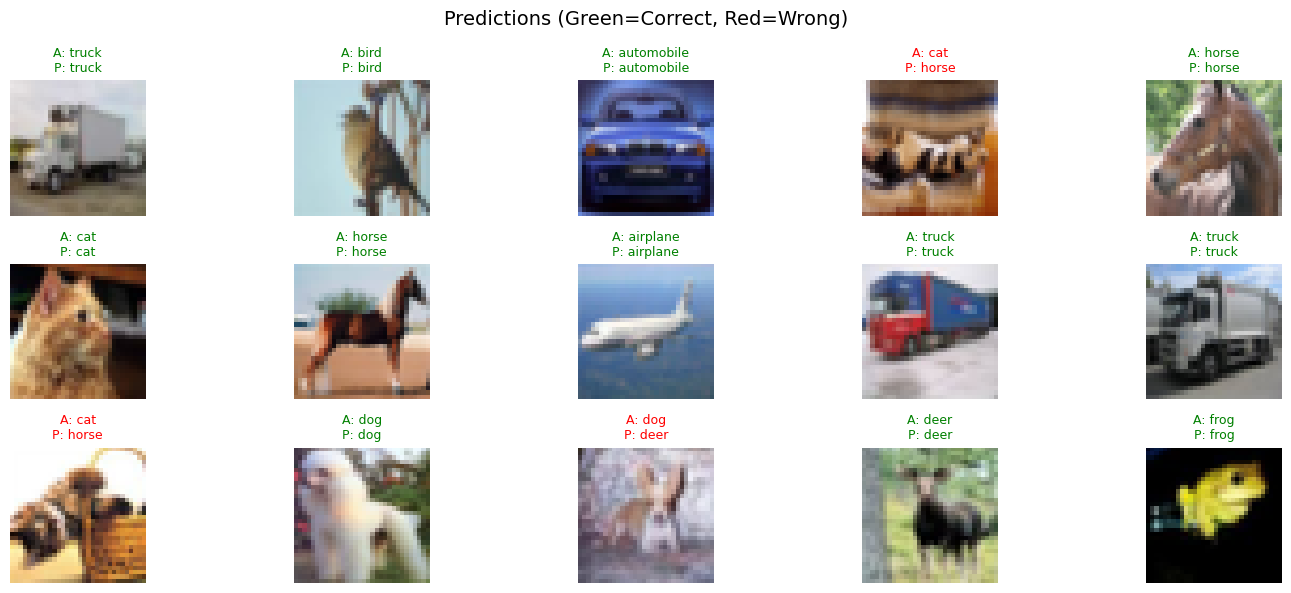


Sample Accuracy: 12/15 (80.0%)


In [40]:
import random
random.seed(42)
indices = random.sample(range(len(x_te)), 15)

# Make predictions using best model (cnn5)
preds = cnn5.predict(x_te[indices])
pred_classes = np.argmax(preds, axis=1)
actual_classes = y_te[indices].flatten()

# Display predictions
plt.figure(figsize=(15, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_te[indices[i]])
    actual = class_names[actual_classes[i]]
    predicted = class_names[pred_classes[i]]
    color = 'green' if actual == predicted else 'red'
    plt.title(f"A: {actual}\nP: {predicted}", fontsize=9, color=color)
    plt.axis('off')
plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()

# Accuracy on these samples
correct = (pred_classes == actual_classes).sum()
print(f"\nSample Accuracy: {correct}/15 ({correct/15*100:.1f}%)")

## Step 18: Single Image Prediction

Predict class for a single test image with probability distribution

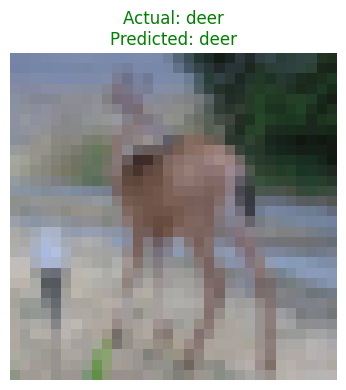


Prediction Probabilities:
  airplane     : 0.0000
  automobile   : 0.0000
  bird         : 0.0028
  cat          : 0.0005
  deer         : 0.9256
  dog          : 0.0010
  frog         : 0.0000
  horse        : 0.0701
  ship         : 0.0000
  truck        : 0.0000


In [41]:

# Pick one test image
idx = 100
single_img = x_te[idx:idx+1]

# Predict using the best model (cnn2)
pred = cnn2.predict(single_img, verbose=0)
pred_class = np.argmax(pred)
actual_class = y_te[idx][0]

# Show image and prediction
plt.figure(figsize=(4, 4))
plt.imshow(x_te[idx])
plt.title(f"Actual: {class_names[actual_class]}\nPredicted: {class_names[pred_class]}",
          fontsize=12, color='green' if pred_class == actual_class else 'red')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nPrediction Probabilities:")
for i, prob in enumerate(pred[0]):
    print(f"  {class_names[i]:12s} : {prob:.4f}")